# RegimeX — Data Collection & Exploratory Analysis

This notebook documents the initial data science pipeline for RegimeX.

Project goal:
Build a regime-aware reinforcement learning trading system for Indian equities.

Initial dataset:
- RELIANCE
- TCS
- HDFCBANK
- ICICIBANK
- INFY

Period: 2015–2025
Frequency: Daily

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (14, 7)

## 1. Load Raw Data

We collected daily OHLCV data for five major Indian stocks using Yahoo Finance.

The raw files are stored in:

data/raw/

Each stock has its own CSV file.

In [4]:
import pandas as pd
import os

stocks = [
    "RELIANCE",
    "TCS",
    "HDFCBANK",
    "ICICIBANK",
    "INFY"
]

raw_data = {}

# Go one level up from notebooks/ to RegimeX/
base_path = ".."

for name in stocks:
    file_path = os.path.join(base_path, "data", "raw", f"{name}.csv")

    df = pd.read_csv(file_path)

    raw_data[name] = df

    print(f"{name}: {df.shape}")

RELIANCE: (2718, 7)
TCS: (2718, 7)
HDFCBANK: (2718, 7)
ICICIBANK: (2718, 7)
INFY: (2718, 7)


## 2. Raw Data Validation

Before cleaning, we checked:

- Number of rows
- Columns
- Missing values
- Duplicate rows
- First and last observations
- Date range

This ensures that the downloaded data is structurally correct before further analysis.

In [5]:
for name, df in raw_data.items():

    print("=" * 60)
    print(f"Checking: {name}")
    print("=" * 60)

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nFirst 3 rows:")
    print(df.head(3))

    print("\nLast 3 rows:")
    print(df.tail(3))

Checking: RELIANCE
Rows: 2718
Columns: 7

Column names:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Missing values:
Price        0
Adj Close    1
Close        1
High         1
Low          1
Open         1
Volume       1
dtype: int64

Duplicate rows: 0

First 3 rows:
        Price          Adj Close               Close               High  \
0      Ticker        RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
1        Date                NaN                 NaN                NaN   
2  2015-01-01  189.1253662109375  202.95899963378906  203.8961944580078   

                  Low                Open       Volume  
0         RELIANCE.NS         RELIANCE.NS  RELIANCE.NS  
1                 NaN                 NaN          NaN  
2  201.98751831054688  202.59327697753906      2963643  

Last 3 rows:
           Price           Adj Close               Close                High  \
2715  2025-12-29  1538.4866943359375  1545.5999755859375  1558.0999755859375   
2716  2

## 3. Data Cleaning

The raw Yahoo Finance files were cleaned to create analysis-ready datasets.

Cleaning included:

- Removing the extra Yahoo Finance header rows
- Converting Date to datetime
- Converting numerical columns to numeric values
- Removing invalid rows
- Removing duplicate dates
- Sorting chronologically
- Checking missing values

Cleaned datasets are stored in:

data/processed/

In [7]:
import os
import pandas as pd

BASE_DIR = ".."

clean_data = {}

for name in stocks:

    print(f"\nCleaning {name}...")

    file_path = os.path.join(
        BASE_DIR,
        "data",
        "raw",
        f"{name}.csv"
    )

    df = pd.read_csv(file_path, skiprows=[1])

    # Rename first column to Date
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)

    # Convert Date
    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    # Convert numerical columns
    numeric_columns = [
        "Adj Close",
        "Close",
        "High",
        "Low",
        "Open",
        "Volume"
    ]

    for col in numeric_columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # Remove invalid rows
    df = df.dropna()

    # Remove duplicate dates
    df = df.drop_duplicates(
        subset="Date"
    )

    # Sort by date
    df = df.sort_values(
        "Date"
    ).reset_index(drop=True)

    # Save cleaned dataset
    output_path = os.path.join(
        BASE_DIR,
        "data",
        "processed",
        f"{name}_clean.csv"
    )

    os.makedirs(
        os.path.dirname(output_path),
        exist_ok=True
    )

    df.to_csv(
        output_path,
        index=False
    )

    clean_data[name] = df

    print(f"Saved: {output_path}")
    print(f"Rows: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Duplicate dates: {df['Date'].duplicated().sum()}")
    print(
        f"Date range: "
        f"{df['Date'].min().date()} → "
        f"{df['Date'].max().date()}"
    )


Cleaning RELIANCE...
Saved: ../data/processed/RELIANCE_clean.csv
Rows: 2716
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Missing values: 0
Duplicate dates: 0
Date range: 2015-01-01 → 2025-12-31

Cleaning TCS...
Saved: ../data/processed/TCS_clean.csv
Rows: 2716
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Missing values: 0
Duplicate dates: 0
Date range: 2015-01-01 → 2025-12-31

Cleaning HDFCBANK...
Saved: ../data/processed/HDFCBANK_clean.csv
Rows: 2716
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Missing values: 0
Duplicate dates: 0
Date range: 2015-01-01 → 2025-12-31

Cleaning ICICIBANK...
Saved: ../data/processed/ICICIBANK_clean.csv
Rows: 2716
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Missing values: 0
Duplicate dates: 0
Date range: 2015-01-01 → 2025-12-31

Cleaning INFY...
Saved: ../data/processed/INFY_clean.csv
Rows: 2716
Columns: ['Date', 'Adj Close', 'Close', 'High',

/var/folders/yz/_9n78y055gd314g07pmzsvvr0000gp/T/ipykernel_21253/2987012203.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(
/var/folders/yz/_9n78y055gd314g07pmzsvvr0000gp/T/ipykernel_21253/2987012203.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(
/var/folders/yz/_9n78y055gd314g07pmzsvvr0000gp/T/ipykernel_21253/2987012203.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(
/var/folders/yz/_9n78y055gd314g07pmzsvvr0000gp/T/ipykernel_21253/2987012203.py:25: UserWarning: Could not 

## 4. Daily Return Analysis

Daily returns measure the percentage change in the adjusted closing price from one trading day to the next.

Formula:

Return(t) = [Price(t) / Price(t-1)] - 1

Daily returns are important for:
- Volatility analysis
- Risk measurement
- Market regime detection
- Reinforcement learning rewards

In [8]:
returns = {}

for name, df in clean_data.items():

    df = df.copy()

    df["Daily_Return"] = df["Adj Close"].pct_change()

    returns[name] = df

    daily_returns = df["Daily_Return"].dropna()

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Number of return observations:", len(daily_returns))
    print("Mean daily return:", round(daily_returns.mean(), 6))
    print("Daily volatility:", round(daily_returns.std(), 6))
    print("Minimum daily return:", round(daily_returns.min(), 6))
    print("Maximum daily return:", round(daily_returns.max(), 6))
    print("Median daily return:", round(daily_returns.median(), 6))

RELIANCE
Number of return observations: 2715
Mean daily return: 0.000924
Daily volatility: 0.017095
Minimum daily return: -0.131539
Maximum daily return: 0.14718
Median daily return: 0.000665
TCS
Number of return observations: 2715
Mean daily return: 0.000534
Daily volatility: 0.014626
Minimum daily return: -0.094103
Maximum daily return: 0.098451
Median daily return: 0.000177
HDFCBANK
Number of return observations: 2715
Mean daily return: 0.000657
Daily volatility: 0.013949
Minimum daily return: -0.126069
Maximum daily return: 0.115996
Median daily return: 0.000596
ICICIBANK
Number of return observations: 2715
Mean daily return: 0.000743
Daily volatility: 0.019183
Minimum daily return: -0.178479
Maximum daily return: 0.146877
Median daily return: 0.000139
INFY
Number of return observations: 2715
Mean daily return: 0.000684
Daily volatility: 0.016616
Minimum daily return: -0.161881
Maximum daily return: 0.120334
Median daily return: 0.000513


## 5. Normalized Stock Performance

To compare stocks with very different prices, we normalize all stocks to a starting value of 100.

Formula:

Normalized Price =
(Current Price / Initial Price) × 100

This allows us to compare relative growth over the same period.

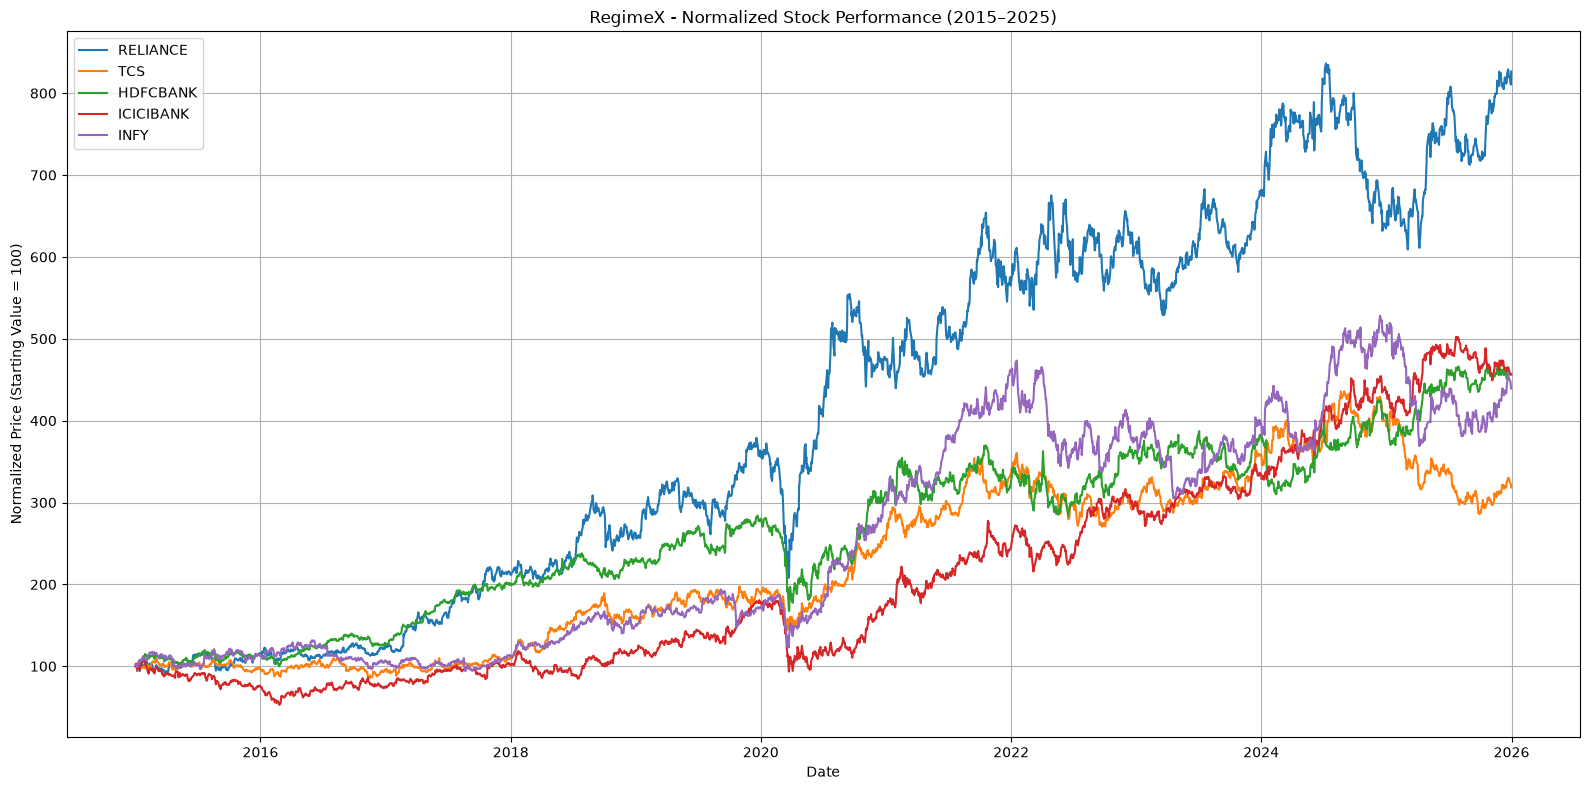

In [9]:
plt.figure(figsize=(16, 8))

for name, df in clean_data.items():

    normalized = (
        df["Adj Close"] / df["Adj Close"].iloc[0]
    ) * 100

    plt.plot(
        df["Date"],
        normalized,
        label=name
    )

plt.title("RegimeX - Normalized Stock Performance (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Starting Value = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Rolling Volatility

We calculate 20-day rolling volatility to observe how market risk changes over time.

Rolling volatility:

σ(t) = Standard deviation of daily returns over the previous 20 trading days

Higher values indicate a period of greater price uncertainty and risk.

This is particularly important for RegimeX because market volatility will later influence regime classification and trading decisions.

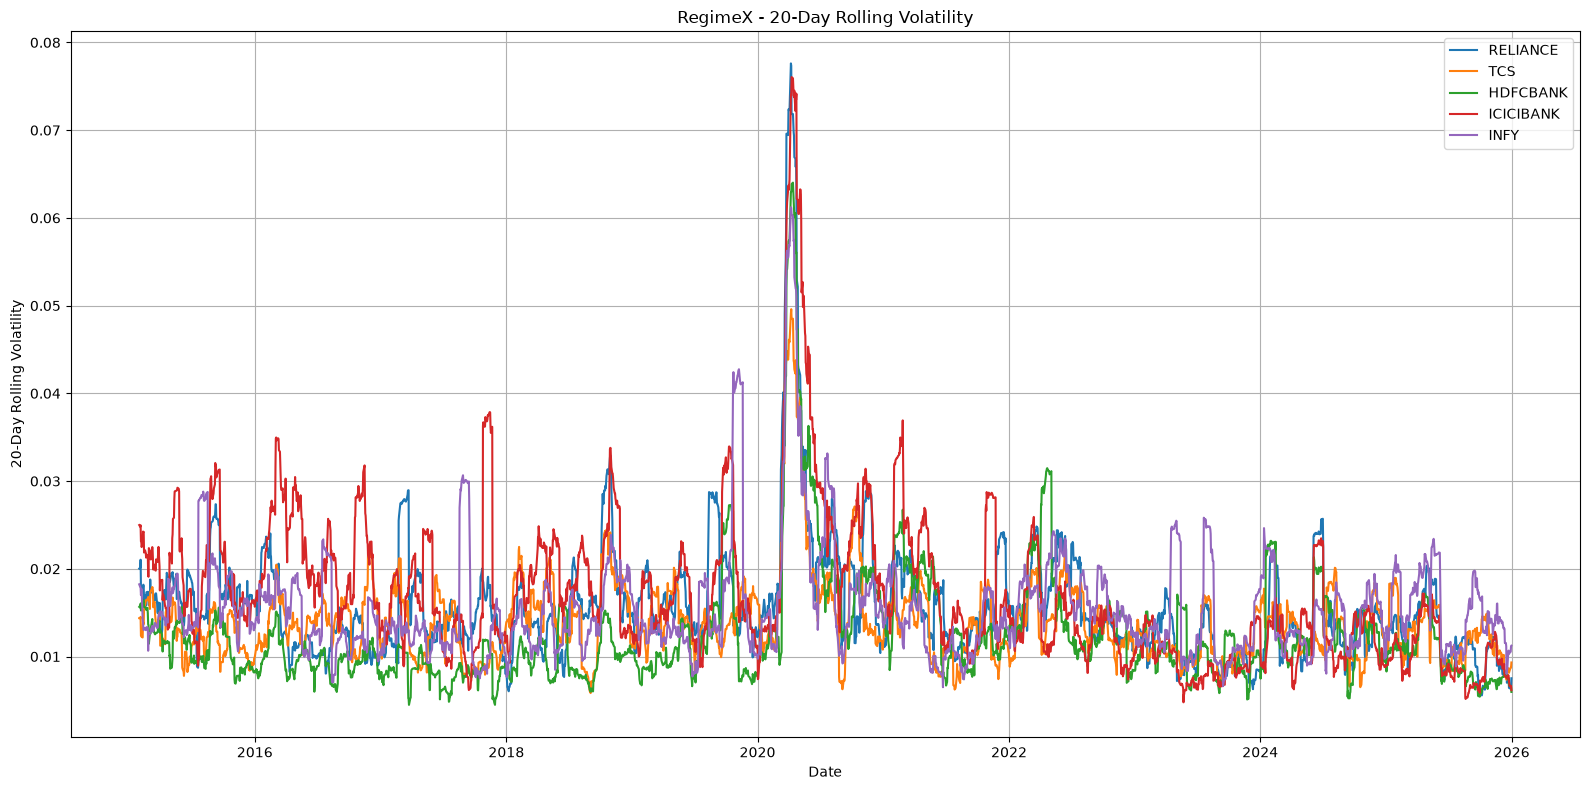

In [10]:
plt.figure(figsize=(16, 8))

for name, df in returns.items():

    rolling_volatility = (
        df["Daily_Return"]
        .rolling(window=20)
        .std()
    )

    plt.plot(
        df["Date"],
        rolling_volatility,
        label=name
    )

plt.title("RegimeX - 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("20-Day Rolling Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Rolling Hurst Exponent

The Hurst exponent is used to investigate the long-term dependence and behavior of financial returns.

Interpretation:

H < 0.5  → mean-reverting / anti-persistent behavior

H ≈ 0.5 → approximately random-walk behavior

H > 0.5  → persistent / trending behavior

We calculate the Hurst exponent using a rolling 100-day window.

This provides another signal that can help distinguish different market regimes.

In [11]:
def hurst_exponent(series):

    series = np.asarray(series)

    if len(series) < 20:
        return np.nan

    lags = range(2, 20)

    tau = []

    for lag in lags:
        differences = series[lag:] - series[:-lag]
        tau.append(np.std(differences))

    tau = np.array(tau)

    if np.any(tau <= 0):
        return np.nan

    slope = np.polyfit(
        np.log(list(lags)),
        np.log(tau),
        1
    )[0]

    return slope

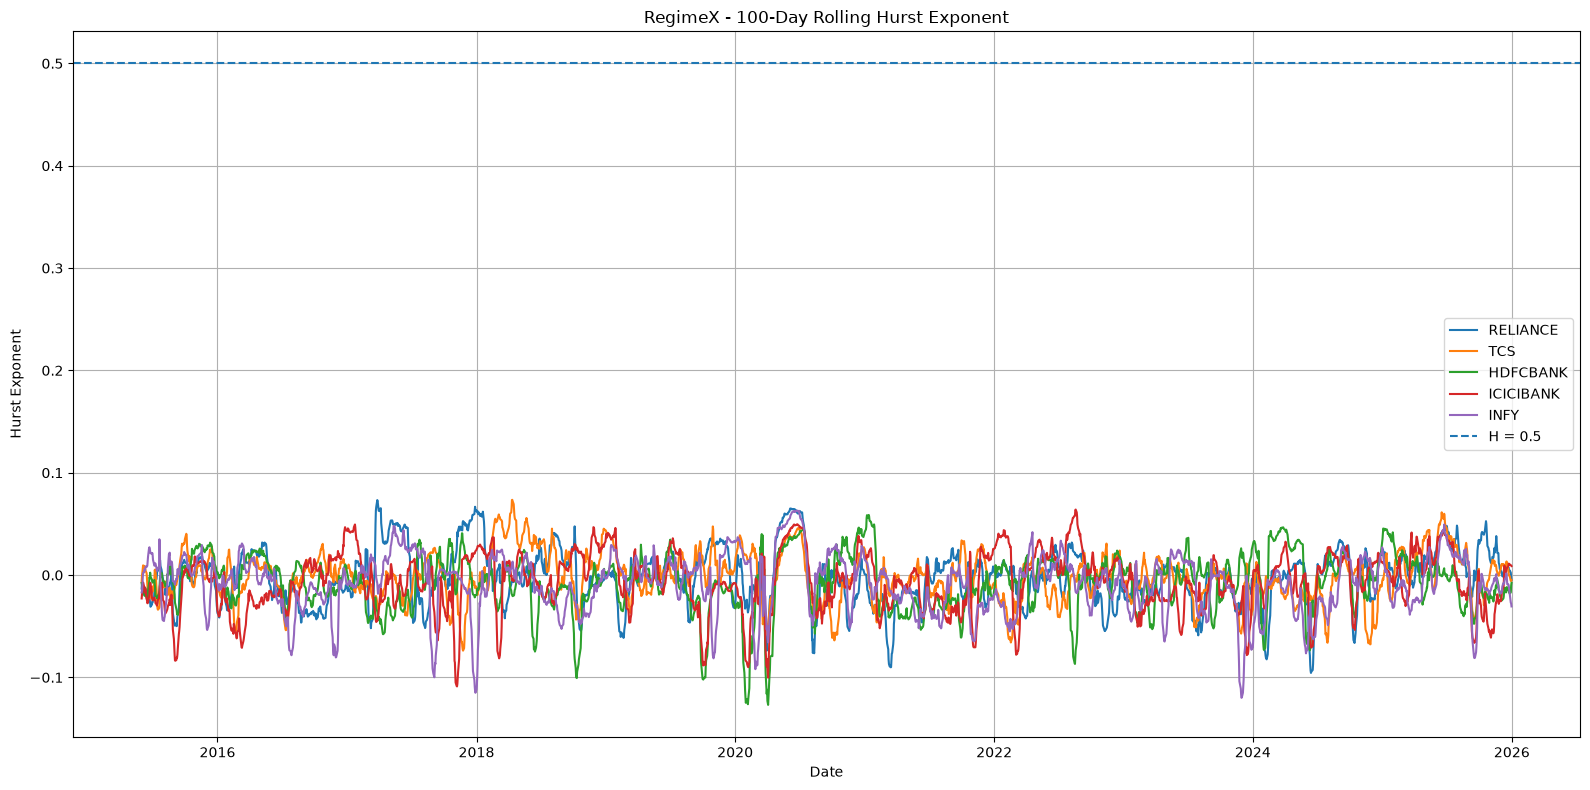

In [12]:
plt.figure(figsize=(16, 8))

for name, df in returns.items():

    hurst_values = (
        df["Daily_Return"]
        .rolling(window=100)
        .apply(hurst_exponent, raw=True)
    )

    plt.plot(
        df["Date"],
        hurst_values,
        label=name
    )

plt.axhline(
    0.5,
    linestyle="--",
    label="H = 0.5"
)

plt.title("RegimeX - 100-Day Rolling Hurst Exponent")
plt.xlabel("Date")
plt.ylabel("Hurst Exponent")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Regime Feature Engineering

After analysing returns, volatility, and market memory, we create a feature dataset for identifying different market regimes.

Features used:

- Daily Return → price movement
- Rolling Volatility → market uncertainty
- Hurst Exponent → trend/mean-reversion behaviour

In [13]:
import pandas as pd

regime_features = pd.read_csv(
    "../data/processed/RELIANCE_regime_features.csv"
)

regime_features["Date"] = pd.to_datetime(
    regime_features["Date"]
)

regime_features.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility,Hurst
0,2015-05-29,189.157227,200.467453,202.627563,199.575974,201.130341,29277517.0,0.001370,0.016532,0.292412
1,2015-06-01,194.603302,206.239166,206.844925,200.696030,201.153198,19594976.0,0.028791,0.016116,0.321514
2,2015-06-02,193.826843,205.416275,210.022217,203.770477,207.039215,20178960.0,-0.003990,0.016161,0.378092
3,2015-06-03,193.330750,204.890533,208.113556,203.096161,205.496277,15546279.0,-0.002559,0.015830,0.417905
4,2015-06-04,196.857224,208.627869,209.427902,204.021912,206.684906,15931395.0,0.018241,0.015960,0.449682


## Feature Selection

The clustering model uses:

1. Daily Return
2. Rolling Volatility
3. Hurst Exponent

These represent price movement, risk, and market behaviour.

In [14]:
features = [
    "Daily_Return",
    "Rolling_Volatility",
    "Hurst"
]

X = regime_features[features]

X.head()

,Daily_Return,Rolling_Volatility,Hurst
0,0.001370,0.016532,0.292412
1,0.028791,0.016116,0.321514
2,-0.003990,0.016161,0.378092
3,-0.002559,0.015830,0.417905
4,0.018241,0.015960,0.449682


## Feature Scaling

Since the features have different scales, standardization is applied before clustering.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.02440487,  0.13950084, -2.13536824],
       [ 1.62962179,  0.08108608, -1.92748913],
       [-0.289373  ,  0.08736403, -1.52335009],
       [-0.20563301,  0.04087486, -1.23896344],
       [ 1.01199327,  0.05905586, -1.01197027]])

## KMeans Market Regime Detection

KMeans clustering groups similar market conditions together.

We use 3 clusters:

- Normal market
- Weak bearish/uncertain market
- High volatility market

In [16]:
from sklearn.cluster import KMeans


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


regime_features["Regime"] = kmeans.fit_predict(
    X_scaled
)


regime_features["Regime"].value_counts()

Regime
1    1472
0    1114
2      31
Name: count, dtype: int64

## Understanding Detected Regimes

Clusters are interpreted using average:

- Return
- Volatility
- Hurst exponent

In [17]:
regime_features.groupby("Regime")[
    [
        "Daily_Return",
        "Rolling_Volatility",
        "Hurst"
    ]
].mean()

,Daily_Return,Rolling_Volatility,Hurst
Regime,,,
0,-0.000136,0.016527,0.718909
1,0.001407,0.013858,0.492783
2,0.018560,0.059874,0.688114


## Assigning Market Regime Names

Cluster numbers are converted into meaningful market states.

In [18]:
regime_mapping = {
    0: "Weak_Bear",
    1: "Normal_Market",
    2: "High_Volatility"
}


regime_features["Market_Regime"] = (
    regime_features["Regime"]
    .map(regime_mapping)
)


regime_features[
    [
        "Date",
        "Regime",
        "Market_Regime"
    ]
].head()

,Date,Regime,Market_Regime
0,2015-05-29,1,Normal_Market
1,2015-06-01,1,Normal_Market
2,2015-06-02,1,Normal_Market
3,2015-06-03,1,Normal_Market
4,2015-06-04,1,Normal_Market


In [19]:
regime_features["Market_Regime"].value_counts()

Market_Regime
Normal_Market      1472
Weak_Bear          1114
High_Volatility      31
Name: count, dtype: int64

## Final Regime Dataset

This dataset will later become the input for the Reinforcement Learning trading environment.

In [20]:
regime_features.to_csv(
    "../data/processed/RELIANCE_final_regime_dataset.csv",
    index=False
)

print("Final regime dataset saved!")

Final regime dataset saved!
